# Pengaturan Awal & Import Library

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # Use imblearn's pipeline for SMOTE

import warnings
warnings.filterwarnings("ignore")


In [61]:
df = pd.read_csv('../training_dataset.csv')
df

,customer_number,usia,pekerjaan,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,...,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau,berlangganan_deposito
0,531036,63,sosial media specialis,menikah,Pendidikan Tinggi,no,yes,no,cellular,jul,...,999,0,nonexistent,-1.7,94.215,-40.3,0.885,4991.6,Papua,1
1,999241,43,teknisi,menikah,Pendidikan Tinggi,no,yes,no,cellular,nov,...,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,Sulawesi,0
2,995002,29,sosial media specialis,lajang,Pendidikan Tinggi,no,yes,yes,cellular,jul,...,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,Papua,0
3,932750,40,pekerja kasar,menikah,SMA,no,no,no,telephone,may,...,999,0,nonexistent,1.1,93.994,-36.4,4.859,5191.0,Sumatera,1
4,684699,40,sosial media specialis,lajang,Pendidikan Tinggi,no,no,no,cellular,aug,...,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,Bali,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22911,680377,32,teknisi,menikah,Diploma,no,yes,no,cellular,aug,...,999,0,nonexistent,1.4,93.444,-36.1,4.967,5228.1,Kalimantan,0
22912,505429,30,mahasiswa,lajang,Diploma,no,no,no,telephone,sep,...,999,0,nonexistent,-1.1,94.199,-37.5,0.880,4963.6,Bali,0
22913,308952,29,manajer,lajang,SMA,no,yes,no,cellular,jul,...,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,NTT,0
22914,865813,52,entrepreneur,menikah,Tidak Tamat SD,unknown,yes,no,telephone,jun,...,999,0,nonexistent,1.4,94.465,-41.8,4.960,5228.1,NTB,0


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22916 entries, 0 to 22915
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_number               22916 non-null  int64  
 1   usia                          22916 non-null  int64  
 2   pekerjaan                     22916 non-null  object 
 3   status_perkawinan             22916 non-null  object 
 4   pendidikan                    22916 non-null  object 
 5   gagal_bayar_sebelumnya        22916 non-null  object 
 6   pinjaman_rumah                22916 non-null  object 
 7   pinjaman_pribadi              22916 non-null  object 
 8   jenis_kontak                  22916 non-null  object 
 9   bulan_kontak_terakhir         22916 non-null  object 
 10  hari_kontak_terakhir          22916 non-null  object 
 11  jumlah_kontak_kampanye_ini    22916 non-null  int64  
 12  hari_sejak_kontak_sebelumnya  22916 non-null  int64  
 13  j

In [63]:
df.describe(include='all')

,customer_number,usia,pekerjaan,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,...,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau,berlangganan_deposito
count,22916.000000,22916.000000,22916,22916,22916,22916,22916,22916,22916,22916,...,22916.000000,22916.000000,22916,22916.000000,22916.000000,22916.000000,22916.000000,22916.000000,22916,22916.000000
unique,NaN,NaN,12,4,8,3,3,3,2,10,...,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,8,NaN
top,NaN,NaN,sosial media specialis,menikah,Pendidikan Tinggi,no,yes,no,cellular,may,...,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,Jawa,NaN
freq,NaN,NaN,5755,13858,6699,18169,12053,18888,14523,7611,...,NaN,NaN,19836,NaN,NaN,NaN,NaN,NaN,2973,NaN
mean,550930.993193,40.016233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,962.210377,0.170143,NaN,0.077915,93.576541,-40.485717,3.617890,5166.773124,NaN,0.114069
std,259909.889175,10.438059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,187.566774,0.490611,NaN,1.576176,0.580586,4.641091,1.737591,72.479698,NaN,0.317902
min,100108.000000,17.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN,0.000000
25%,325755.000000,32.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN,0.000000
50%,553139.000000,38.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,999.000000,0.000000,NaN,1.100000,93.876000,-41.800000,4.857000,5191.000000,NaN,0.000000
75%,777157.500000,47.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN,0.000000


In [64]:
df_validation = pd.read_csv('../validation_set.csv')
df_validation

,customer_number,usia,pekerjaan,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,...,jumlah_kontak_kampanye_ini,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau
0,445420,35,penyedia jasa,menikah,SMA,no,yes,yes,cellular,jul,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,Jawa
1,585604,52,teknisi,lajang,Diploma,unknown,no,no,telephone,may,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,Papua
2,888824,37,pekerja kasar,menikah,SMP,unknown,yes,no,telephone,may,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,Bali
3,816820,51,pengangguran,menikah,Diploma,no,no,no,telephone,may,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,Sumatera
4,542716,45,teknisi,cerai,SMA,no,yes,no,cellular,may,...,1,999,1,failure,-1.8,92.893,-46.2,1.327,5099.1,Sumatera
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5724,782072,51,pekerja kasar,menikah,Tidak Tamat SD,no,yes,no,telephone,jun,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1,Kalimantan
5725,116371,30,pekerja kasar,menikah,SMP,no,yes,yes,telephone,may,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,Sulawesi
5726,773759,45,pekerja kasar,menikah,SMP,unknown,yes,no,telephone,may,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,NTB
5727,612330,60,teknisi,menikah,Diploma,unknown,no,no,telephone,jul,...,15,999,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1,Papua


In [65]:
df_validation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5729 entries, 0 to 5728
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_number               5729 non-null   int64  
 1   usia                          5729 non-null   int64  
 2   pekerjaan                     5729 non-null   object 
 3   status_perkawinan             5729 non-null   object 
 4   pendidikan                    5729 non-null   object 
 5   gagal_bayar_sebelumnya        5729 non-null   object 
 6   pinjaman_rumah                5729 non-null   object 
 7   pinjaman_pribadi              5729 non-null   object 
 8   jenis_kontak                  5729 non-null   object 
 9   bulan_kontak_terakhir         5729 non-null   object 
 10  hari_kontak_terakhir          5729 non-null   object 
 11  jumlah_kontak_kampanye_ini    5729 non-null   int64  
 12  hari_sejak_kontak_sebelumnya  5729 non-null   int64  
 13  jum

In [66]:
df_validation.describe(include='all')

,customer_number,usia,pekerjaan,status_perkawinan,pendidikan,gagal_bayar_sebelumnya,pinjaman_rumah,pinjaman_pribadi,jenis_kontak,bulan_kontak_terakhir,...,jumlah_kontak_kampanye_ini,hari_sejak_kontak_sebelumnya,jumlah_kontak_sebelumnya,hasil_kampanye_sebelumnya,tingkat_variasi_pekerjaan,indeks_harga_konsumen,indeks_kepercayaan_konsumen,suku_bunga_euribor_3bln,jumlah_pekerja,pulau
count,5729.000000,5729.000000,5729,5729,5729,5729,5729,5729,5729,5729,...,5729.000000,5729.000000,5729.000000,5729,5729.000000,5729.000000,5729.000000,5729.000000,5729.000000,5729
unique,NaN,NaN,12,4,8,2,3,3,2,10,...,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,8
top,NaN,NaN,sosial media specialis,menikah,Pendidikan Tinggi,no,yes,no,cellular,may,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,Sulawesi
freq,NaN,NaN,1458,3503,1732,4522,2960,4725,3667,1941,...,NaN,NaN,NaN,4988,NaN,NaN,NaN,NaN,NaN,748
mean,548493.630826,39.852679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.545470,964.329377,0.162157,NaN,0.096003,93.571413,-40.471356,3.638297,5167.914662,NaN
std,258992.541542,10.348971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.618704,182.310129,0.471306,NaN,1.565580,0.576929,4.632091,1.727321,71.802171,NaN
min,100423.000000,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN
25%,323527.000000,32.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN
50%,552893.000000,38.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,999.000000,0.000000,NaN,1.100000,93.444000,-41.800000,4.857000,5191.000000,NaN
75%,772131.000000,46.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN


# Exploratory Data Analysis

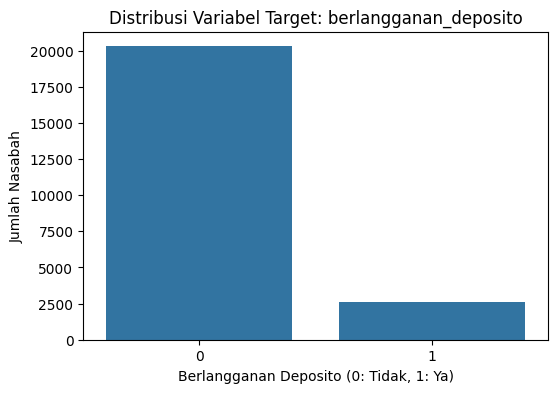

berlangganan_deposito
0    0.885931
1    0.114069
Name: proportion, dtype: float64
Terlihat jelas adanya ketidakseimbangan kelas (imbalanced class).


In [67]:
plt.figure(figsize=(6, 4))
sns.countplot(x='berlangganan_deposito', data=df)
plt.title('Distribusi Variabel Target: berlangganan_deposito')
plt.xlabel('Berlangganan Deposito (0: Tidak, 1: Ya)')
plt.ylabel('Jumlah Nasabah')
plt.show()
print(df['berlangganan_deposito'].value_counts(normalize=True))
print("Terlihat jelas adanya ketidakseimbangan kelas (imbalanced class).")

In [68]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('customer_number') # Remove customer_number from analysis
numeric_cols.remove('berlangganan_deposito') # Remove target from features for distribution analysis

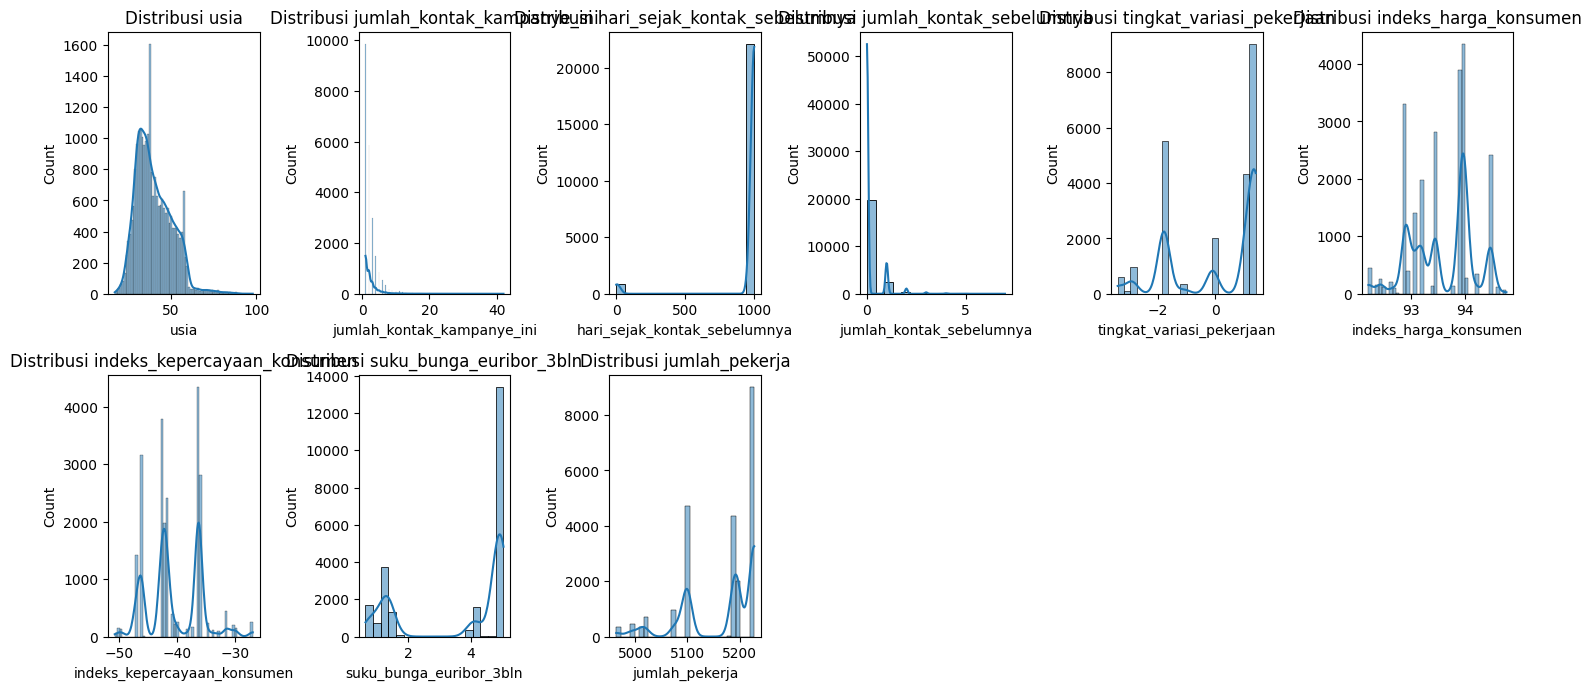

In [69]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 6, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
    plt.tight_layout()
plt.show()

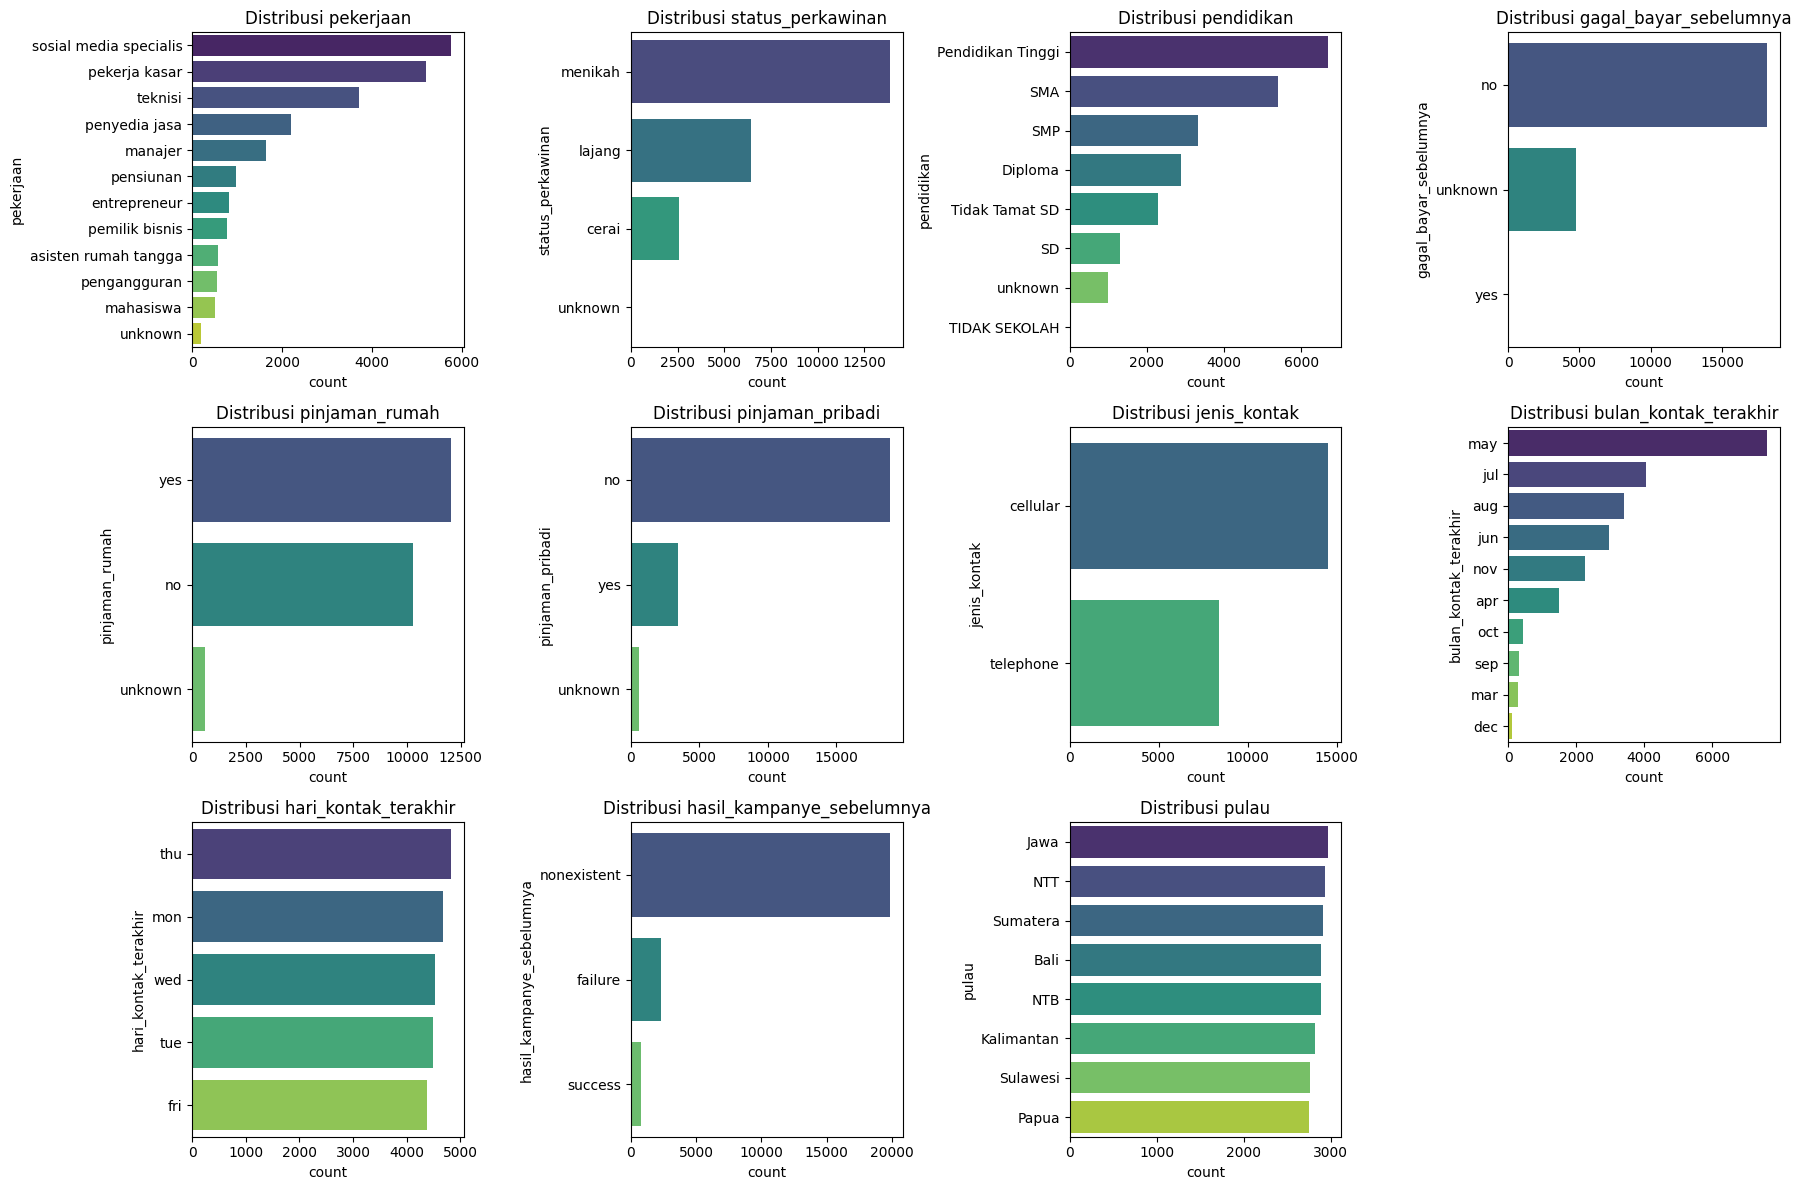

In [70]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 4, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribusi {col}')
    plt.tight_layout()
plt.show()

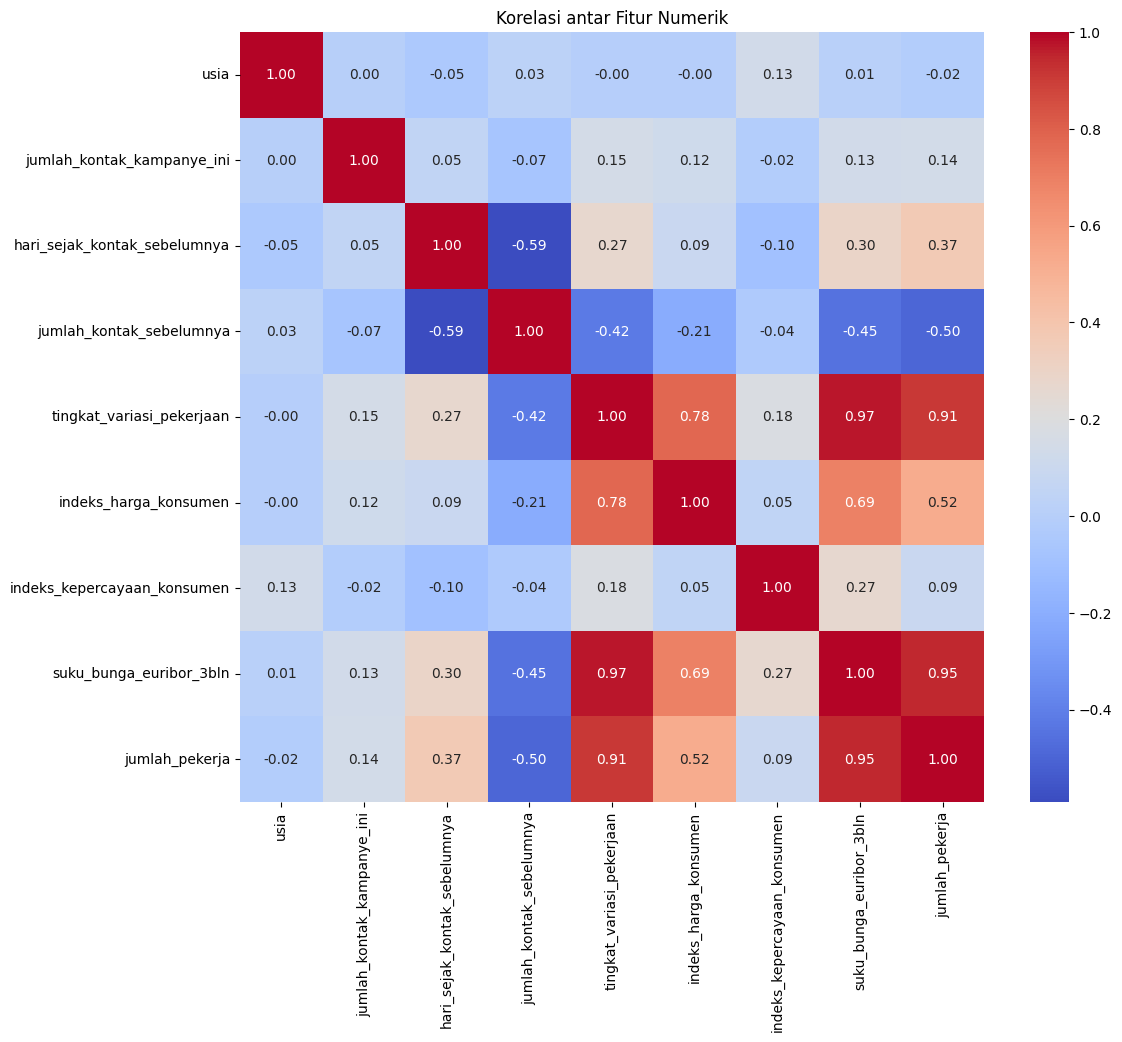

In [71]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi antar Fitur Numerik')
plt.show()

EDA Selesai. Insight:

- Distribusi target sangat tidak seimbang
- Kolom 'hari_sejak_kontak_sebelumnya' didominasi oleh nilai 999, mengindikasikan tidak ada kontak sebelumnya
- Beberapa kolom kategorikal memiliki nilai 'unknown'
- Beberapa fitur numerik menunjukkan skewness atau distribusi yang tidak normal.


# Preprocessing Data

In [72]:
X = df.drop(columns=['customer_number', 'berlangganan_deposito'])
y = df['berlangganan_deposito']

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Ukuran X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Ukuran X_test: {X_test.shape}, y_test: {y_test.shape}")
print("Distribusi target di training set:")
print(y_train.value_counts(normalize=True))
print("Distribusi target di test set:")
print(y_test.value_counts(normalize=True))

Ukuran X_train: (18332, 20), y_train: (18332,)
Ukuran X_test: (4584, 20), y_test: (4584,)
Distribusi target di training set:
berlangganan_deposito
0    0.885937
1    0.114063
Name: proportion, dtype: float64
Distribusi target di test set:
berlangganan_deposito
0    0.885908
1    0.114092
Name: proportion, dtype: float64


In [74]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

Penanganan khusus untuk 'hari_sejak_kontak_sebelumnya' (pdays) <br />
Kita akan buat fitur biner baru 'is_new_customer_contact' <br />
yang bernilai 1 jika pdays == 999 (tidak ada kontak sebelumnya), dan 0 jika ada kontak. <br />
Lalu kolom aslinya akan di-transform (misalnya diganti 999 dengan 0 atau rata-rata) <br />
Untuk kesederhanaan, mari kita ubah 999 menjadi -1 atau 0 (sesuai interpretasi bisnis) <br />
Disini aku akan buat kolom baru, dan kolom lama 999 tetap dipertahankan atau bisa juga di-transform. <br />
Untuk model, lebih baik 999 diperlakukan sebagai missing value atau flag. <br />
Aku akan buat flag dan mengganti 999 dengan -1 agar StandardScaler tidak terlalu terpengaruh ekstrem. <br />


In [75]:
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

In [76]:
X_train_processed['is_new_contact'] = (X_train_processed['hari_sejak_kontak_sebelumnya'] == 999).astype(int)
X_test_processed['is_new_contact'] = (X_test_processed['hari_sejak_kontak_sebelumnya'] == 999).astype(int)

In [ ]:
# Mengganti 999 di 'hari_sejak_kontak_sebelumnya' dengan -1 atau 0
# -1 lebih baik agar StandardScaler tidak memperlakukan 999 sebagai nilai valid yang besar
X_train_processed['hari_sejak_kontak_sebelumnya'] = X_train_processed['hari_sejak_kontak_sebelumnya'].replace(999, -1)
X_test_processed['hari_sejak_kontak_sebelumnya'] = X_test_processed['hari_sejak_kontak_sebelumnya'].replace(999, -1)

In [78]:
# Perbarui daftar fitur numerik karena ada penambahan 'is_new_contact' dan 'hari_sejak_kontak_sebelumnya' sudah di-transform
numerical_features = X_train_processed.select_dtypes(include=np.number).columns.tolist()
print(f"Fitur Numerik setelah penanganan pdays: {numerical_features}")
print(f"Fitur Kategorikal: {categorical_features}")

Fitur Numerik setelah penanganan pdays: ['usia', 'jumlah_kontak_kampanye_ini', 'hari_sejak_kontak_sebelumnya', 'jumlah_kontak_sebelumnya', 'tingkat_variasi_pekerjaan', 'indeks_harga_konsumen', 'indeks_kepercayaan_konsumen', 'suku_bunga_euribor_3bln', 'jumlah_pekerja', 'is_new_contact']
Fitur Kategorikal: ['pekerjaan', 'status_perkawinan', 'pendidikan', 'gagal_bayar_sebelumnya', 'pinjaman_rumah', 'pinjaman_pribadi', 'jenis_kontak', 'bulan_kontak_terakhir', 'hari_kontak_terakhir', 'hasil_kampanye_sebelumnya', 'pulau']


In [79]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) # handle_unknown='ignore' untuk data test baru
    ])

## Penanganan Imbalanced Class

SMOTE akan diaplikasikan setelah split dan sebelum scaling/encoding, dan hanya pada training data. Best practice adalah memasukkannya ke dalam pipeline imb.


# Model Training & Hyperparameter Tuning

In [80]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'), # liblinear cocok untuk dataset kecil & L1/L2 penalty
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting (LightGBM)': LGBMClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42, n_estimators=100) # eval_metric for internal use, use_label_encoder=False to suppress warning
}

In [81]:
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.1, 1, 10], # Inverse of regularization strength
        'classifier__penalty': ['l1', 'l2']
    },
    'Random Forest': {
        'classifier__n_estimators': [50, 100, 200], # Number of trees
        'classifier__max_depth': [5, 10, None] # Max depth of trees
    },
    'Gradient Boosting (LightGBM)': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__num_leaves': [20, 31, 40]
    },
    'XGBoost': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__max_depth': [3, 5, 7],
        'classifier__subsample': [0.8, 1.0]
    }
}


best_models = {}
results = []

# Menggunakan StratifiedKFold untuk cross-validation agar proporsi kelas tetap terjaga
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [82]:
for name, model in models.items():
    if model is None: # Skip if model was not imported (e.g., LightGBM)
        continue

    print(f"\n--- Melatih dan Tuning Model: {name} ---")

    # Buat pipeline lengkap: Preprocessing -> SMOTE -> Classifier
    # Perhatikan bahwa SMOTE harus diterapkan *setelah* preprocessing (terutama encoding)
    # dan *sebelum* classifier, serta hanya pada data training.
    # ImbPipeline dari imblearn memastikan ini dilakukan dengan benar dalam cross-validation.
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42, sampling_strategy='auto')), # sampling_strategy='auto' default ke minority class
        ('classifier', model)
    ])

    # Gunakan GridSearchCV untuk tuning hyperparameter
    grid_search = GridSearchCV(pipeline, param_grids[name], cv=cv_strategy, scoring='roc_auc', n_jobs=-1, verbose=0)

    grid_search.fit(X_train_processed, y_train)

    best_models[name] = grid_search.best_estimator_
    print(f"Model terbaik untuk {name}: {grid_search.best_params_}")
    print(f"Skor AUC Cross-Validation terbaik untuk {name}: {grid_search.best_score_:.4f}")

    # Evaluasi pada test set
    y_pred_proba = best_models[name].predict_proba(X_test_processed)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"Skor AUC pada Test Set untuk {name}: {auc_score:.4f}")

    # Simpan hasil
    results.append({
        'Model': name,
        'Best Params': grid_search.best_params_,
        'CV AUC Score': grid_search.best_score_,
        'Test AUC Score': auc_score
    })


--- Melatih dan Tuning Model: Logistic Regression ---
Model terbaik untuk Logistic Regression: {'classifier__C': 0.1, 'classifier__penalty': 'l1'}
Skor AUC Cross-Validation terbaik untuk Logistic Regression: 0.7873
Skor AUC pada Test Set untuk Logistic Regression: 0.7877

--- Melatih dan Tuning Model: Random Forest ---
Model terbaik untuk Random Forest: {'classifier__max_depth': 10, 'classifier__n_estimators': 200}
Skor AUC Cross-Validation terbaik untuk Random Forest: 0.7870
Skor AUC pada Test Set untuk Random Forest: 0.7884

--- Melatih dan Tuning Model: Gradient Boosting (LightGBM) ---
[LightGBM] [Info] Number of positive: 16241, number of negative: 16241
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004399 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16137
[LightGBM] [Info] Number of data points in the train set: 32482, number

In [83]:
results_df = pd.DataFrame(results)
print("\n--- Ringkasan Hasil Model ---")
print(results_df.sort_values(by='Test AUC Score', ascending=False))


--- Ringkasan Hasil Model ---
                          Model  \
3                       XGBoost   
2  Gradient Boosting (LightGBM)   
1                 Random Forest   
0           Logistic Regression   

                                         Best Params  CV AUC Score  \
3  {'classifier__learning_rate': 0.05, 'classifie...      0.792979   
2  {'classifier__learning_rate': 0.05, 'classifie...      0.788437   
1  {'classifier__max_depth': 10, 'classifier__n_e...      0.787001   
0  {'classifier__C': 0.1, 'classifier__penalty': ...      0.787320   

   Test AUC Score  
3        0.792324  
2        0.788831  
1        0.788387  
0        0.787655  


# Prediksi & Evaluasi (ROC AUC)

In [84]:
best_model_name = results_df.sort_values(by='Test AUC Score', ascending=False).iloc[0]['Model']
final_model = best_models[best_model_name]
print(f"\nModel terbaik yang dipilih berdasarkan Test AUC Score adalah: {best_model_name}")


Model terbaik yang dipilih berdasarkan Test AUC Score adalah: XGBoost


In [85]:
# Prediksi probabilitas pada test set menggunakan model terbaik
y_pred_proba_final = final_model.predict_proba(X_test_processed)[:, 1]

# Hitung ROC AUC Score
final_auc = roc_auc_score(y_test, y_pred_proba_final)
print(f"Final ROC AUC Score pada Test Set dengan model {best_model_name}: {final_auc:.4f}")

Final ROC AUC Score pada Test Set dengan model XGBoost: 0.7923


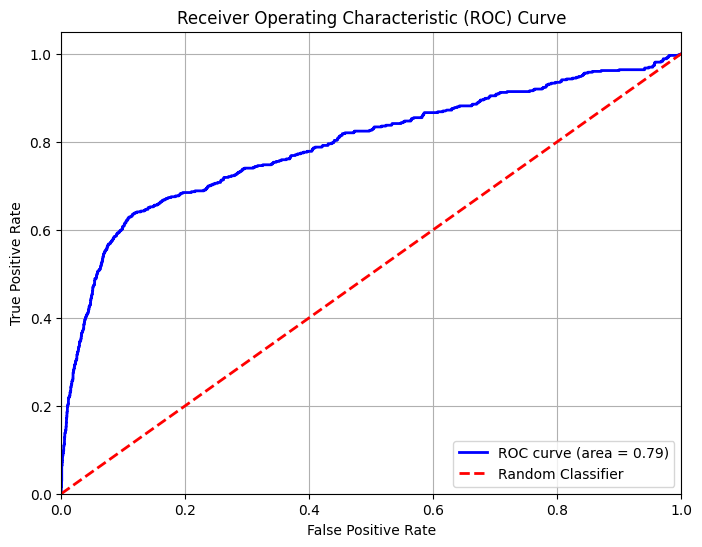

In [86]:
# Visualisasi Kurva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_final)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {final_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Preprocessing Data Validasi

In [87]:
customer_numbers_validation = df_validation['customer_number']
X_validation = df_validation.drop(columns=['customer_number'])

X_validation_processed = X_validation.copy()
X_validation_processed['is_new_contact'] = (X_validation_processed['hari_sejak_kontak_sebelumnya'] == 999).astype(int)
X_validation_processed['hari_sejak_kontak_sebelumnya'] = X_validation_processed['hari_sejak_kontak_sebelumnya'].replace(999, -1)

# Prediksi Proba pake Data Validasi

In [88]:
validation_probabilities = final_model.predict_proba(X_validation_processed)[:, 1]
print("Prediksi probabilitas berhasil dilakukan.")
print(f"Jumlah prediksi probabilitas: {len(validation_probabilities)}")
print(f"Contoh 10 probabilitas pertama: {validation_probabilities[:10]}")

Prediksi probabilitas berhasil dilakukan.
Jumlah prediksi probabilitas: 5729
Contoh 10 probabilitas pertama: [0.0553709  0.04033735 0.03178908 0.04026573 0.07782054 0.03505458
 0.05731753 0.03023496 0.33552262 0.07656056]


# Buat Submission

In [89]:
submission_df = pd.DataFrame({
    'customer_number': customer_numbers_validation,
    'predicted_probability': validation_probabilities
})

print("DataFrame submission berhasil dibuat:")
print(submission_df.head())

DataFrame submission berhasil dibuat:
   customer_number  predicted_probability
0           445420               0.055371
1           585604               0.040337
2           888824               0.031789
3           816820               0.040266
4           542716               0.077821


In [90]:
itsmyfirsttime_uWu = 'itsmyfirsttime_uWu.csv'
submission_df.to_csv(itsmyfirsttime_uWu, index=False)
print(f"\nHasil prediksi disimpan ke file: {itsmyfirsttime_uWu}")


Hasil prediksi disimpan ke file: itsmyfirsttime_uWu.csv
